

**ARCH 594/508: AI Seminar/Studio**  

Spring 2026  



**Instructor:** Narjes Abbasabadi, Ph.D. Assistant Professor  

Email: nabbasab@uw.edu  



**TA:** Hasib Hossain, MSDT Student



Email: hasib97@uw.edu





Department of Architecture  

College of Built Environments  

University of Washington  

Website: [https://silab.be.uw.edu](https://silab.be.uw.edu)

# Exploratory Data Analysis in Pandas



In this notebook we will introduce the **pandas** library — the main Python library for dataframe manipulation and analysis. We will cover the full EDA workflow: loading data, exploring its structure, indexing, filtering, visualization, outlier removal, correlation, and linear regression.



**Useful keyboard shortcuts (Google Colab):**

- `Ctrl + Enter` (Windows) / `Cmd + Enter` (Mac) — run the current cell

- `Shift + Enter` — run the current cell and move to the next one

- `Ctrl + M + A` (Windows) / `Cmd + M + A` (Mac) — insert a cell above

- `Ctrl + M + B` (Windows) / `Cmd + M + B` (Mac) — insert a cell below

- `Ctrl + S` (Windows) / `Cmd + S` (Mac) — save the notebook



**Additional resources:**

- [Whirlwind Tour of Python](https://jakevdp.github.io/WhirlwindTourOfPython/) (great book by a UW alum)

- [Google Colab Overview](https://colab.research.google.com/notebooks/basic_features_overview.ipynb) (official introduction to Colab)

- [Python Basics — Google Research](https://colab.research.google.com/github/data-psl/lectures2020/blob/master/notebooks/01_python_basics.ipynb) (more comprehensive)

---

## Before You Begin — A Brief Orientation



This notebook assumes no prior programming experience. The sections below provide essential background that will help you follow the material with confidence.



### What is Google Colab?



Google Colab (short for Colaboratory) is a free, browser-based environment for writing and running Python code. It requires no installation — everything runs in the cloud through your Google account. The document you are reading right now is a **Colab notebook**, made up of **cells**. There are two kinds:

- **Text cells** (like this one) contain explanations and instructions. You simply read them.

- **Code cells** (they have a gray background with a play button on the left) contain Python code. You **run** them by clicking the play button or pressing `Shift + Enter`.



**Important:** Run every code cell **from top to bottom**, in order. Each cell often depends on the one above it. Skipping a cell may cause errors in later cells. If you encounter unexpected errors, go to **Runtime > Run all** to re-run every cell from the beginning.



### What is Python?



Python is a programming language — a way of giving instructions to a computer. You do not need to memorize anything at this stage. Instead, focus on **reading** the code and the comments (lines starting with `#`) to understand what each instruction does.



### What are libraries?



Libraries (also called packages) are collections of pre-built tools that extend what Python can do. Rather than writing everything from scratch, we import libraries that others have already written and tested. The main ones used in this notebook are:



- **pandas** — for working with tables of data (similar to working with spreadsheets, but in code)

- **matplotlib** — for creating charts and graphs

- **numpy** — for numerical and mathematical operations



Most of these libraries come pre-installed in Google Colab. In the next cell, we will `import` them so they are available throughout the notebook.



### Key terminology



| Term | Meaning |

|---|---|

| **Variable** | A named container that stores a value (e.g., `x = 5` stores the number 5 in `x`) |

| **DataFrame** | A table of data with rows and columns — the pandas equivalent of a spreadsheet |

| **Column** | A single vertical field in a table (e.g., "Age" or "Name") |

| **Row** | A single horizontal entry in a table (e.g., one building or one animal) |

| **Function** | A reusable instruction, such as `print()`, which displays text on screen |

| **Index** | The position number of an item — Python counts starting from **0**, not 1 |

| **Filter** | Keeping only the rows that meet a condition (e.g., "age > 30") |

| **String** | Text data, always written inside quotes: `'hello'` or `"Seattle"` |

| **Boolean** | A True/False value, used to evaluate conditions |

| `#` (hash) | Marks a **comment** — Python ignores everything after it; comments are notes for the reader |

### Importing libraries



The cell below loads all the libraries we need. The `import ... as ...` syntax gives each library a short nickname so we do not have to type the full name every time. For example, `import pandas as pd` means "load the pandas library and refer to it as `pd` for short."



Run the cell below by clicking on it and pressing `Shift + Enter`. You should see no output — that means it ran successfully.

In [1]:
# Import necessary packages

import pandas as pd        # For working with tables (DataFrames)

import numpy as np         # For numerical/math operations

import matplotlib.pyplot as plt  # For creating charts and plots

import seaborn as sn       # For statistical visualizations

import plotly.express as px # For interactive plots

import gdown               # For downloading files from Google Drive

---

## 1. Introduction to Pandas



A `DataFrame` is the core pandas data structure — a two-dimensional table with labeled rows and columns. Let's build a small one from scratch to learn the basics.



> **Conceptual note:** A DataFrame is essentially a spreadsheet represented in code. Each column has a header, and each row is one record. The difference is that instead of pointing and clicking, we use code to inspect and manipulate the data.

### Creating a DataFrame from scratch



In the cell below, we create a small table about animals in a zoo. Here is what each part of the code does:



```python
zoo = pd.DataFrame({ ... })
```



- `pd.DataFrame(...)` tells pandas to create a new table.

- `zoo =` stores that table in a variable called `zoo` so we can reference it later.

- Inside the curly braces `{ }`, each line defines one **column**: the column name (in quotes) followed by a list of values in square brackets `[ ]`.

In [2]:
# Create a simple DataFrame

zoo = pd.DataFrame({

    'Animal':   ['elephant', 'bear', 'whale', 'turtle', 'monkey', 'panda'],

    'Age':      [40, 20, 50, 100, 5, 10],

    'Type':     ['land', 'land', 'water', 'both', 'land', 'land'],

    'Visitors': [80, 30, 90, 200, 10, 30]

})



zoo

,Animal,Age,Type,Visitors
0,elephant,40,land,80
1,bear,20,land,30
2,whale,50,water,90
3,turtle,100,both,200
4,monkey,5,land,10
5,panda,10,land,30


The output above shows a table with 6 rows and 4 columns. The numbers on the far left (0, 1, 2, ...) are the **index** — pandas automatically numbers each row starting from 0.

In [3]:
# Print the column names

zoo.columns

Index(['Animal', 'Age', 'Type', 'Visitors'], dtype='object')

This returns the names of all four columns in our zoo table.

### Selecting a single column



There are two ways to select a single column from a DataFrame. Both return the same result — just the data from that one column.

In [4]:
# Select a single column by name

zoo['Animal']

,Animal
0,elephant
1,bear
2,whale
3,turtle
4,monkey
5,panda


In [5]:
# Select a single column using dot notation

zoo.Age

,Age
0,40
1,20
2,50
3,100
4,5
5,10


Both methods retrieve a single column. However, `zoo['Animal']` (bracket notation) is more reliable because it works even when column names contain spaces or special characters. `zoo.Age` (dot notation) is a convenient shortcut that only works with simple column names.

### Filtering rows



Filtering means selecting only the rows where a given condition is true. The general pattern is:



```python
dataframe[ dataframe.column == some_value ]
```



Read this as: *"From the dataframe, return the rows where the column equals some value."*



Common comparison operators:



| Operator | Meaning |

|---|---|

| `==` | is equal to (note: two equals signs, not one) |

| `>=` | greater than or equal to |

| `<=` | less than or equal to |

| `!=` | is not equal to |

In [6]:
# Filter rows: only the panda

zoo[zoo.Animal == 'panda']

,Animal,Age,Type,Visitors
5,panda,10,land,30


This reads: *"From the zoo table, return only the rows where the Animal column equals 'panda'."* The result is a single row.

In [7]:
# Filter rows: animals 40 years or older

zoo[zoo.Age >= 40]

,Animal,Age,Type,Visitors
0,elephant,40,land,80
2,whale,50,water,90
3,turtle,100,both,200


In [8]:
# Filter rows: land animals only

land = zoo[zoo.Type == 'land']

land

,Animal,Age,Type,Visitors
0,elephant,40,land,80
1,bear,20,land,30
4,monkey,5,land,10
5,panda,10,land,30


Here we saved the filtered result into a new variable called `land`. This is now its own smaller DataFrame that we can use independently.

### Your first chart



A **scatter plot** places a dot for each row. The horizontal position (x-axis) represents one variable, and the vertical position (y-axis) represents another. This allows us to visually inspect whether two variables appear to be related.



The standard code pattern for a scatter plot is:



```python
plt.scatter(x=..., y=...)   # Plot the dots
plt.title('...')            # Add a title
plt.xlabel('...')           # Label the x-axis
plt.ylabel('...')           # Label the y-axis
plt.show()                  # Display the chart
```

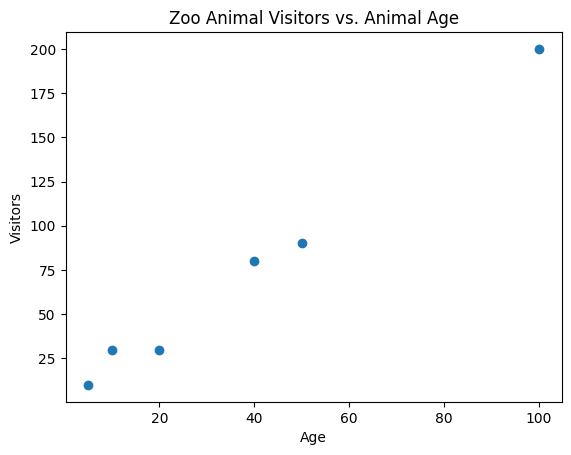

In [9]:
# Quick scatter plot: animal age vs. visitor count

plt.scatter(x=zoo.Age, y=zoo.Visitors)

plt.title('Zoo Animal Visitors vs. Animal Age')

plt.xlabel('Age')

plt.ylabel('Visitors')

plt.show()

Each dot represents one animal. The chart suggests that older animals tend to attract more visitors.

---

## 2. Loading and Exploring a Real Dataset



We will now work with the Seattle **Energy Benchmarking** dataset, which contains annual energy consumption information for individual buildings larger than 20,000 square feet in Seattle.



> **Context:** The City of Seattle requires large buildings to report their energy usage every year. This public dataset allows researchers, architects, and urban planners to study which buildings consume the most energy and investigate contributing factors.

### Download the dataset

The cell below downloads the dataset file from Google Drive. The `!` at the beginning of the line tells Colab to run this as a system command rather than Python code. You do not need to understand the details — simply run the cell.

In [10]:
## NOTE: MAKE SURE YOU RUN THIS CELL



# Download the CSV from Google Drive

!gdown --id 19enMQ2D0Mv3IUq8ExyAHj8LWrKU0XFdm

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=19enMQ2D0Mv3IUq8ExyAHj8LWrKU0XFdm
To: /content/2021_Building_Energy_Benchmarking.csv
100% 1.20M/1.20M [00:00<00:00, 12.5MB/s]


In [11]:
# Verify the file is present

!ls *.csv

2021_Building_Energy_Benchmarking.csv


You should see the filename `2021_Building_Energy_Benchmarking.csv` printed above. A **CSV** (Comma-Separated Values) file is one of the most common formats for storing tabular data — it is essentially a spreadsheet saved as plain text.

### Reading the CSV into a DataFrame



The next cell loads the CSV file into a pandas DataFrame, converting the file contents into a table we can explore with code.

In [12]:
# Read the CSV into a DataFrame

building_energy = pd.read_csv("2021_Building_Energy_Benchmarking.csv")

The entire spreadsheet is now stored in a variable called `building_energy`. No output is displayed because we have only loaded the data — we have not yet asked to view it. The following cells will do that.

### Inspect the DataFrame



Before diving into analysis, it is good practice to get a quick overview of your data. The next few cells demonstrate different ways to examine a DataFrame. Think of this as opening a spreadsheet and scanning the headers, the first few rows, and the column types to understand what you are working with.

In [13]:
# Display the first few rows

building_energy.head()

,OSEBuildingID,DataYear,BuildingName,BuildingType,TaxParcelIdentificationNumber,Address,City,State,ZipCode,Latitude,...,ThirdLargestPropertyUseTypeGFA,Electricity(kWh),SteamUse(kBtu),NaturalGas(therms),ComplianceStatus,ComplianceIssue,Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
0,1,2021,MAYFLOWER PARK HOTEL,NonResidential,659000030,405 OLIVE WAY,SEATTLE,WA,98101,47.61220,...,0,944955,1798672,14876,Compliant,No Issue,3224187,1487620,241.6,2.7
1,2,2021,PARAMOUNT HOTEL,NonResidential,659000220,724 PINE ST,SEATTLE,WA,98101,47.61307,...,0,657478,0,23738,Compliant,No Issue,2243315,2373790,135.4,1.5
2,3,2021,WESTIN HOTEL (Parent Building),NonResidential,659000475,1900 5TH AVE,SEATTLE,WA,98101,47.61367,...,0,8673722,10583473,37750,Compliant,No Issue,29594739,3775000,1201.4,1.6
3,5,2021,HOTEL MAX,NonResidential,659000640,620 STEWART ST,SEATTLE,WA,98101,47.61412,...,0,509497,1167770,19676,Compliant,No Issue,1738403,1967580,208.6,3.4
4,8,2021,WARWICK SEATTLE HOTEL,NonResidential,659000970,401 LENORA ST,SEATTLE,WA,98121,47.61375,...,0,1333597,0,68087,Compliant,No Issue,4550233,6808700,380.4,3.3


`.head()` displays the **first 5 rows** of the table. This is a quick way to verify that the data loaded correctly and to get a sense of what the columns look like.

In [14]:
# Confirm the variable type

type(building_energy)

pandas.core.frame.DataFrame

This confirms that `building_energy` is a `DataFrame` — the pandas table structure introduced in Section 1.

In [15]:
# List all column names

building_energy.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingName', 'BuildingType',
       'TaxParcelIdentificationNumber', 'Address', 'City', 'State', 'ZipCode',
       'Latitude', 'Longitude', 'Neighborhood', 'CouncilDistrictCode',
       'YearBuilt', 'NumberofFloors', 'NumberofBuildings', 'PropertyGFATotal',
       'PropertyGFABuilding(s)', 'PropertyGFAParking', 'ENERGYSTARScore',
       'SiteEUIWN(kBtu/sf)', 'SiteEUI(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SourceEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)',
       'EPAPropertyType', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'Electricity(kWh)', 'SteamUse(kBtu)',
       'NaturalGas(therms)', 'ComplianceStatus', 'ComplianceIssue',
       'Electricity(kBtu)', 'NaturalGas(kBtu)', 'TotalGHGEmissions',
       'GHGEmissionsIntensity'],
      dtype='object')

In [16]:
# Data types and non-null counts

building_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3663 non-null   int64  
 1   DataYear                         3663 non-null   int64  
 2   BuildingName                     3663 non-null   object 
 3   BuildingType                     3663 non-null   object 
 4   TaxParcelIdentificationNumber    3663 non-null   object 
 5   Address                          3663 non-null   object 
 6   City                             3663 non-null   object 
 7   State                            3663 non-null   object 
 8   ZipCode                          3663 non-null   int64  
 9   Latitude                         3663 non-null   float64
 10  Longitude                        3663 non-null   float64
 11  Neighborhood                     3661 non-null   object 
 12  CouncilDistrictCode 

`.info()` provides a summary of every column: its name, how many non-empty values it contains, and its **data type** (`float64` = decimal number, `int64` = whole number, `object` = text). This is useful for identifying columns with substantial missing data.

In [17]:
# Descriptive statistics for numeric columns

building_energy.describe()

,OSEBuildingID,DataYear,ZipCode,Latitude,Longitude,CouncilDistrictCode,YearBuilt,NumberofFloors,NumberofBuildings,PropertyGFATotal,...,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,Electricity(kWh),SteamUse(kBtu),NaturalGas(therms),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,3663.000000,3663.0,3663.000000,3663.000000,3663.000000,3663.000000,3663.000000,3663.000000,3663.000000,3.663000e+03,...,3.663000e+03,3663.00000,3663.000000,3.663000e+03,3.663000e+03,3.663000e+03,3.663000e+03,3.663000e+03,3663.000000,3663.000000
mean,23922.210483,2021.0,96643.509419,47.598941,-122.268003,2.689326,1973.129675,5.056784,1.166530,1.070735e+05,...,8.663969e+04,17906.29484,2743.545182,9.340146e+05,2.925918e+05,1.521752e+04,3.529597e+06,1.550744e+06,118.291974,1.217882
std,14331.756851,0.0,11933.848036,1.113665,2.858293,2.229124,34.712470,5.701001,2.180697,2.332236e+05,...,2.832689e+05,47019.72011,14642.040441,2.570627e+06,4.454561e+06,7.531615e+04,1.756966e+07,7.594444e+06,568.240613,2.145308
min,1.000000,2021.0,0.000000,0.000000,-122.414250,0.000000,1896.000000,0.000000,0.000000,2.000000e+04,...,0.000000e+00,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,20296.500000,2021.0,98104.000000,47.601425,-122.350505,1.000000,1953.000000,3.000000,1.000000,2.964100e+04,...,2.586550e+04,0.00000,0.000000,1.764520e+05,0.000000e+00,0.000000e+00,6.147670e+05,0.000000e+00,5.200000,0.100000
50%,23615.000000,2021.0,98112.000000,47.619330,-122.332320,1.000000,1980.000000,4.000000,1.000000,4.734300e+04,...,4.160000e+04,0.00000,0.000000,3.304030e+05,0.000000e+00,3.501000e+03,1.148932e+06,3.574000e+05,29.200000,0.600000
75%,26976.000000,2021.0,98122.000000,47.657165,-122.318585,4.000000,2002.000000,6.000000,1.000000,1.015550e+05,...,8.230900e+04,14353.50000,0.000000,7.760675e+05,0.000000e+00,1.363000e+04,2.718398e+06,1.386725e+06,92.950000,1.400000
max,50858.000000,2021.0,98199.000000,47.733870,0.000000,7.000000,2021.000000,76.000000,111.000000,9.320156e+06,...,1.521647e+07,750000.00000,480625.000000,7.925876e+07,1.680307e+08,3.737314e+06,9.191679e+08,3.737314e+08,20445.700000,47.400000


`.describe()` computes basic statistics for every numeric column: the count, mean (average), standard deviation, minimum, maximum, and quartile values. This is a useful way to quickly identify anything unusual in the data.

In [18]:
# Number of rows and columns

building_energy.shape

(3663, 42)

`.shape` returns two numbers in parentheses: `(rows, columns)`. The first number is the count of rows (buildings); the second is the count of columns (data fields recorded for each building).

**Exercise 2.1:** In a markdown cell below, explain in words what the number of rows and columns represent.

*Exercise 2.1*



The number of rows represents the number of individual buildings in the dataset and the number of columns represents the number of data attributes recorded for each building.

**Exercise 2.2:** Write code to display only the number of columns in `building_energy`.



HINT: `.shape` returns a pair of numbers in the form `(rows, columns)`. You can retrieve a single element using square brackets and a position number. In Python, position `[0]` is the first element (rows) and `[1]` is the second (columns).

In [19]:
## Exercise 2.2



building_energy.shape[1]

42

---

## 3. Indexing



"Indexing" refers to selecting elements of the DataFrame based on their row and column labels or positions.



> **Conceptual note:** Indexing is how you point at specific cells in a table and retrieve their values. You can point by **name** ("give me the Electricity column") or by **position** ("give me rows 0 through 4").

In [20]:
# Method 1: bracket notation (recommended — works with any column name)

building_energy['Electricity(kWh)']

,Electricity(kWh)
0,944955
1,657478
2,8673722
3,509497
4,1333597
...,...
3658,97222
3659,0
3660,222388
3661,219761


In [21]:
# Method 2: dot notation (only works when column name has no spaces or special characters)

building_energy.Latitude

,Latitude
0,47.61220
1,47.61307
2,47.61367
3,47.61412
4,47.61375
...,...
3658,47.60826
3659,47.62267
3660,47.61784
3661,47.67767


> **Tip:** Prefer the bracket notation `df["column_name"]` — it makes clear that you are referencing a column by its string name, and it always works even when the column name contains spaces or parentheses.

### Column statistics



Once you have selected a column, you can compute statistics on it using built-in functions such as `.min()`, `.max()`, and `.mean()`.

In [22]:
# Extract a column for convenience

energy = building_energy['Electricity(kWh)']



print("Minimum energy: {}".format(energy.min()))

print("Mean energy:    {}".format(energy.mean()))

Minimum energy: 0
Mean energy:    934014.6399126399


**Reading the print statement:** `"Minimum energy: {}".format(energy.min())` inserts a calculated value into a text message. The `{}` acts as a placeholder that gets replaced by whatever `.format(...)` provides. You do not need to memorize this syntax — you will become familiar with it through repeated exposure in this notebook.

**Exercise 3.1:** Print the **maximum** energy consumption.



HINT: If `.min()` returns the smallest value, what function do you think returns the largest?

In [23]:
## Exercise 3.1



print("Max energy: {}".format(energy.max()))

Max energy: 79258760


### Positional indexing with `iloc`



DataFrames can be indexed numerically using the `iloc` function. The slice `0:n` selects elements at positions 0 through n-1.



> **A note on slicing:** In Python, `0:5` means "start at position 0, stop *before* position 5" — so you get positions 0, 1, 2, 3, 4 (five items total). This convention is a common source of initial confusion, so keep it in mind as you work through the examples.

In [24]:
# First five rows

building_energy.iloc[0:5]

,OSEBuildingID,DataYear,BuildingName,BuildingType,TaxParcelIdentificationNumber,Address,City,State,ZipCode,Latitude,...,ThirdLargestPropertyUseTypeGFA,Electricity(kWh),SteamUse(kBtu),NaturalGas(therms),ComplianceStatus,ComplianceIssue,Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
0,1,2021,MAYFLOWER PARK HOTEL,NonResidential,659000030,405 OLIVE WAY,SEATTLE,WA,98101,47.61220,...,0,944955,1798672,14876,Compliant,No Issue,3224187,1487620,241.6,2.7
1,2,2021,PARAMOUNT HOTEL,NonResidential,659000220,724 PINE ST,SEATTLE,WA,98101,47.61307,...,0,657478,0,23738,Compliant,No Issue,2243315,2373790,135.4,1.5
2,3,2021,WESTIN HOTEL (Parent Building),NonResidential,659000475,1900 5TH AVE,SEATTLE,WA,98101,47.61367,...,0,8673722,10583473,37750,Compliant,No Issue,29594739,3775000,1201.4,1.6
3,5,2021,HOTEL MAX,NonResidential,659000640,620 STEWART ST,SEATTLE,WA,98101,47.61412,...,0,509497,1167770,19676,Compliant,No Issue,1738403,1967580,208.6,3.4
4,8,2021,WARWICK SEATTLE HOTEL,NonResidential,659000970,401 LENORA ST,SEATTLE,WA,98121,47.61375,...,0,1333597,0,68087,Compliant,No Issue,4550233,6808700,380.4,3.3


In [25]:
# First ten rows, first five columns

building_energy.iloc[0:10, 0:5]

,OSEBuildingID,DataYear,BuildingName,BuildingType,TaxParcelIdentificationNumber
0,1,2021,MAYFLOWER PARK HOTEL,NonResidential,659000030
1,2,2021,PARAMOUNT HOTEL,NonResidential,659000220
2,3,2021,WESTIN HOTEL (Parent Building),NonResidential,659000475
3,5,2021,HOTEL MAX,NonResidential,659000640
4,8,2021,WARWICK SEATTLE HOTEL,NonResidential,659000970
5,9,2021,WEST PRECINCT (SEATTLE POLICE),Nonresidential COS,660000560
6,10,2021,CAMLIN WORLDMARK HOTEL,NonResidential,660000825
7,11,2021,PARAMOUNT THEATER,NonResidential,660000955
8,12,2021,COURTYARD BY MARRIOTT - PIONEER SQ,NonResidential,939000080
9,13,2021,LYON BUILDING,Multifamily MR (5-9),939000105


`iloc[0:10, 0:5]` uses two slices separated by a comma: the first slice selects **rows** (positions 0 through 9), and the second selects **columns** (positions 0 through 4).

**Exercise 3.2:** Print the 7th through 11th rows of the `"Electricity(kWh)"` column.



HINT: The rows at positions 7, 8, 9, 10, and 11 can be selected with the slice `7:12` (remember, the end value is exclusive).

In [26]:
## Exercise 3.2



building_energy['Electricity(kWh)'].iloc[7:12]

,Electricity(kWh)
7,758790
8,1662709
9,724208
10,2104697
11,4386609


---

## 4. Filtering



Filtering lets us select rows that satisfy a condition. Pandas applies a boolean mask to the DataFrame, keeping only the rows where the condition is `True`.



> **Analogy:** Filtering works the same way as using a filter dropdown in a spreadsheet application — you specify a condition, and only the rows that meet it are displayed.

### How filtering works step by step



When you write `building_energy['NumberofFloors'] >= 30`, Python does not directly return the matching rows. Instead, it first generates a list of `True` and `False` values — one for every row in the table. Rows marked `True` are kept; rows marked `False` are excluded. This list of True/False values is called a **boolean mask**.



You do not need to create the mask separately. Pandas handles it behind the scenes when you place the condition inside the brackets.

In [27]:
# Buildings with 30 or more floors

building_energy[building_energy['NumberofFloors'] >= 30]

,OSEBuildingID,DataYear,BuildingName,BuildingType,TaxParcelIdentificationNumber,Address,City,State,ZipCode,Latitude,...,ThirdLargestPropertyUseTypeGFA,Electricity(kWh),SteamUse(kBtu),NaturalGas(therms),ComplianceStatus,ComplianceIssue,Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
2,3,2021,WESTIN HOTEL (Parent Building),NonResidential,659000475,1900 5TH AVE,SEATTLE,WA,98101,47.61367,...,0,8673722,10583473,37750,Compliant,No Issue,29594739,3775000,1201.4,1.6
13,18,2021,CROWNE PLAZA,NonResidential,942000235,1113 6TH AVE,SEATTLE,WA,98101,47.60809,...,0,3138801,0,32414,Compliant,No Issue,10709589,3241390,216.5,0.7
48,63,2021,SHERATON GRAND SEATTLE - (Parent Building),Campus,1976700095,1400 6TH AVE,SEATTLE,WA,98101,47.61087,...,0,10504820,4869042,156841,Compliant,No Issue,35842446,15684080,1385.4,1.5
199,328,2021,CENTURYLINK: SEATTLE BELL PLAZA,NonResidential,659000165,1600 7TH AVE,SEATTLE,WA,98101,47.61316,...,11645,6094637,0,134789,Compliant,No Issue,20794901,13478891,801.9,1.0
207,336,2021,1918 EIGHTH AVE,NonResidential,660000650,1918 8TH AVE,SEATTLE,WA,98101,47.61555,...,0,9603027,0,1455,Compliant,No Issue,32765528,145470,143.3,0.2
215,345,2021,999 THIRD AVE,NonResidential,939000435,999 3RD AVE,SEATTLE,WA,98104,47.60505,...,0,9962992,0,0,Compliant,No Issue,33993729,0,140.6,0.1
216,346,2021,1000 2ND AVENUE BUILDING,NonResidential,939000475,1000 2ND AVE,SEATTLE,WA,98104,47.60567,...,10475,4984625,0,0,Compliant,No Issue,17007540,0,70.4,0.2
220,351,2021,1111 3RD AVE BUILDING,NonResidential,942000050,1111 3RD AVE,SEATTLE,WA,98101,47.60655,...,0,7082893,0,2410,Compliant,No Issue,24166831,240990,112.8,0.2
222,353,2021,SAFECO PLAZA / 1001 FOURTH AVENUE,NonResidential,942000300,1001 4TH AVE,SEATTLE,WA,98104,47.60615,...,0,10070360,0,49787,Compliant,No Issue,34360068,4978690,406.6,0.5
223,354,2021,FOURTH & MADISON ( IDX TOWER),NonResidential,942000345,925 4TH AVE,SEATTLE,WA,98104,47.60549,...,95572,9188542,0,0,Not Compliant,Default Data,31351305,0,129.7,0.1


**Exercise 4.1:** Compute the average number of floors for `NonResidential` buildings. Save the result in `avg_height_non_residential`.



HINT: This is a two-step process. First, **filter** the DataFrame to keep only rows where `BuildingType` equals `'NonResidential'`. Then, **calculate** the mean of the `NumberofFloors` column from that filtered result.

In [28]:
## Exercise 4.1



residential_buildings = building_energy[building_energy['BuildingType'] == 'NonResidential']

avg_height_non_residential = residential_buildings['NumberofFloors'].mean()

avg_height_non_residential

np.float64(4.655638082376773)

**Exercise 4.2:** Compute the average number of floors for `Multifamily HR (10+)` buildings. Save the result in `avg_height_multifamily`.



HINT: Follow the same pattern as Exercise 4.1, but change the building type string to `'Multifamily HR (10+)'`.

In [29]:
## Exercise 4.2



multifamily_buildings = building_energy[building_energy['BuildingType'] == 'Multifamily HR (10+)']

avg_height_multifamily = multifamily_buildings['NumberofFloors'].mean()

avg_height_multifamily

np.float64(19.481203007518797)

**Exercise 4.3:** In a markdown cell below, state whether non-residential or multifamily buildings are taller on average.

*Exercise 4.3*



Multifamily buildings are taller on average.

### Combining conditions



Use `&` (and) and `|` (or) to combine multiple conditions. Each individual condition must be wrapped in parentheses.



| Symbol | Meaning | Example |

|---|---|---|

| `&` | AND — both conditions must be true | `(A >= 30) & (B >= 2000)` |

| `\|` | OR — at least one condition must be true | `(A < 1950) \| (A > 2000)` |



> **Common mistake:** Forgetting the parentheses around each condition. Writing `A >= 30 & B >= 2000` will produce an error — the correct form is `(A >= 30) & (B >= 2000)`.

In [30]:
# Buildings with 30+ floors AND built after 2000

filtered_buildings = building_energy[

    (building_energy.NumberofFloors >= 30) & (building_energy.YearBuilt >= 2000)

]

filtered_buildings.head(3)

,OSEBuildingID,DataYear,BuildingName,BuildingType,TaxParcelIdentificationNumber,Address,City,State,ZipCode,Latitude,...,ThirdLargestPropertyUseTypeGFA,Electricity(kWh),SteamUse(kBtu),NaturalGas(therms),ComplianceStatus,ComplianceIssue,Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
207,336,2021,1918 EIGHTH AVE,NonResidential,660000650,1918 8TH AVE,SEATTLE,WA,98101,47.61555,...,0,9603027,0,1455,Compliant,No Issue,32765528,145470,143.3,0.2
223,354,2021,FOURTH & MADISON ( IDX TOWER),NonResidential,942000345,925 4TH AVE,SEATTLE,WA,98104,47.60549,...,95572,9188542,0,0,Not Compliant,Default Data,31351305,0,129.7,0.1
469,659,2021,RUSSELL INVESTMENTS CENTER,NonResidential,9184500000,1301 2ND AVE,SEATTLE,WA,98101,47.60740,...,329335,11153760,1303414,1,Compliant,No Issue,38056629,120,265.6,0.2


**Exercise 4.4:** Find the buildings that were **not** built between 1950 and 2000.



HINT: "Not between 1950 and 2000" means the building was built *before* 1950 **or** *after* 2000. Which operator joins two conditions where either one being true is sufficient?

In [31]:
## Exercise 4.4



building_energy[(building_energy.YearBuilt < 1950) | (building_energy.YearBuilt > 2000)]

,OSEBuildingID,DataYear,BuildingName,BuildingType,TaxParcelIdentificationNumber,Address,City,State,ZipCode,Latitude,...,ThirdLargestPropertyUseTypeGFA,Electricity(kWh),SteamUse(kBtu),NaturalGas(therms),ComplianceStatus,ComplianceIssue,Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
0,1,2021,MAYFLOWER PARK HOTEL,NonResidential,659000030,405 OLIVE WAY,SEATTLE,WA,98101,47.61220,...,0,944955,1798672,14876,Compliant,No Issue,3224187,1487620,241.6,2.7
3,5,2021,HOTEL MAX,NonResidential,659000640,620 STEWART ST,SEATTLE,WA,98101,47.61412,...,0,509497,1167770,19676,Compliant,No Issue,1738403,1967580,208.6,3.4
6,10,2021,CAMLIN WORLDMARK HOTEL,NonResidential,660000825,1619 9TH AVE,SEATTLE,WA,98101,47.61390,...,0,744720,0,28625,Compliant,No Issue,2540985,2862470,162.5,2.0
7,11,2021,PARAMOUNT THEATER,NonResidential,660000955,901 PINE ST,SEATTLE,WA,98101,47.61327,...,0,758790,4248573,4250,Compliant,No Issue,2588992,425020,385.9,3.8
8,12,2021,COURTYARD BY MARRIOTT - PIONEER SQ,NonResidential,939000080,612 2ND AVE,SEATTLE,WA,98104,47.60294,...,0,1662709,0,66045,Compliant,No Issue,5673163,6604500,374.2,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3658,50770,2021,16TH & CHERRY LLC,Multifamily LR (1-4),5646600090,701 16TH AVE,SEATTLE,WA,98122,47.60826,...,0,97222,0,4361,Compliant,No Issue,331720,436070,24.5,0.4
3659,50776,2021,BOYLSTON APARTMENTS (LIHI),Multifamily MR (5-9),6850700480,420 BOYLSTON AVE E,SEATTLE,WA,98102,47.62267,...,0,0,0,0,Compliant,No Issue,25185,0,0.0,0.0
3660,50777,2021,CLAY APARTMENTS (LIHI),Multifamily MR (5-9),6848700065,602 E HOWELL ST,SEATTLE,WA,98122,47.61784,...,0,222388,0,3158,Compliant,No Issue,758789,315750,19.9,0.6
3661,50781,2021,WEBSTER SCHOOL - NEW & REMODELED (SPS-DISTRICT),SPS-District K-12,3693901110,3015 NW 68TH ST,SEATTLE,WA,98117,47.67767,...,0,219761,0,11841,Compliant,No Issue,749824,1184120,66.0,1.3


---

## 5. Data Visualization



Visualization is one of the most powerful tools in data analysis — a well-constructed chart can reveal patterns that remain invisible in a table of numbers. This section covers two essential chart types: **histograms** and **scatter plots**.



**Visualization resources:**

- [Seaborn tutorial](https://seaborn.pydata.org/tutorial/introduction.html)

- [Matplotlib plot types](https://matplotlib.org/stable/plot_types/index.html)

### Histograms



A **histogram** shows how values are *distributed* across a range. It groups values into intervals (called "bins") and displays the count of values in each interval as a bar. For example, a histogram of "Year Built" shows how many buildings were constructed during each time period.



The code pattern is:



```python
plt.hist(data, bins=30)    # bins = the number of intervals (bars)
plt.title('...')           # Chart title
plt.xlabel('...')          # Label for the horizontal axis
plt.ylabel('...')          # Label for the vertical axis
plt.show()                 # Display the chart
```

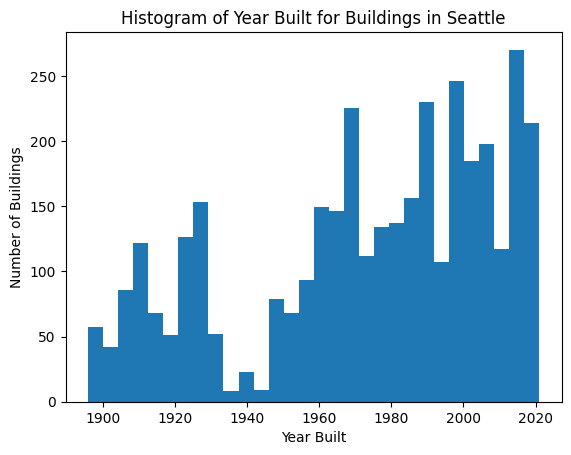

In [32]:
# Histogram of year built

plt.hist(building_energy['YearBuilt'], bins=30)

plt.title('Histogram of Year Built for Buildings in Seattle')

plt.xlabel('Year Built')

plt.ylabel('Number of Buildings')

plt.show()

**Reading this chart:** Each bar represents a range of years. The height of the bar indicates how many buildings in the dataset were constructed during that period. Taller bars correspond to periods with more construction activity.

**Exercise 5.1:** Make a histogram of the number of floors for buildings in Seattle.



HINT: Use the histogram code pattern shown above, replacing `'YearBuilt'` with `'NumberofFloors'`. Remember to update the title and axis labels accordingly.

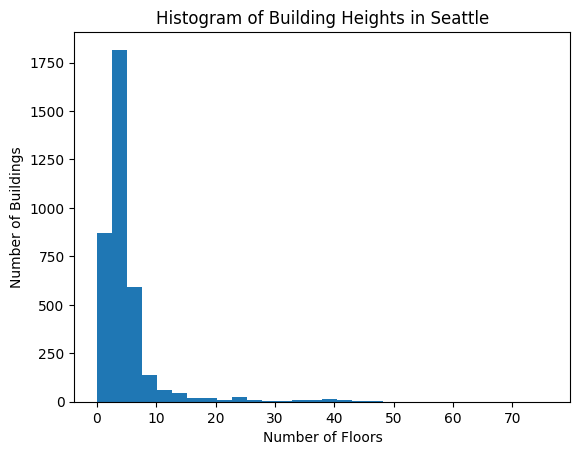

In [33]:
## Exercise 5.1



plt.hist(building_energy['NumberofFloors'], bins=30)

plt.title('Histogram of Building Heights in Seattle')

plt.xlabel('Number of Floors')

plt.ylabel('Number of Buildings')

plt.show()

### Scatter plots



A **scatter plot** places one dot per row, using one column for the horizontal position and another for the vertical. It is used to visually assess whether two variables have a relationship — for example, whether taller buildings tend to consume more energy.

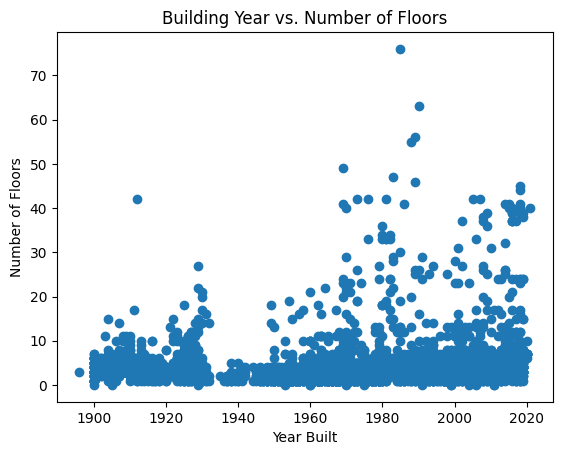

In [34]:
# Is there a relationship between building year and height?

plt.scatter(x=building_energy['YearBuilt'], y=building_energy['NumberofFloors'])

plt.title('Building Year vs. Number of Floors')

plt.xlabel('Year Built')

plt.ylabel('Number of Floors')

plt.show()

**Exercise 5.2:** Create a scatter plot exploring the relationship between building size (Gross Floor Area) and energy consumption.



HINT: Use `'PropertyGFABuilding(s)'` for the x-axis and `'Electricity(kWh)'` for the y-axis. Follow the same `plt.scatter(...)` pattern used above.

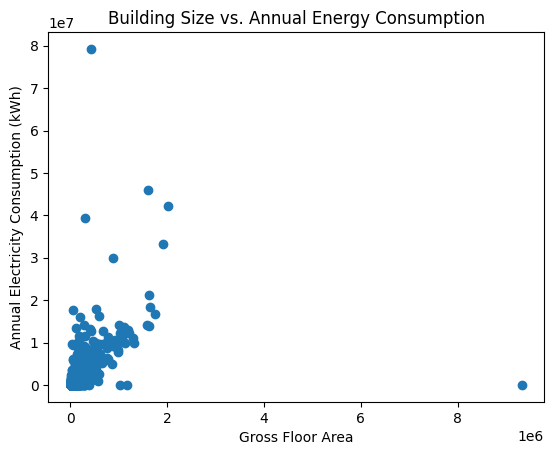

In [35]:
## Exercise 5.2



plt.scatter(x=building_energy['PropertyGFABuilding(s)'], y=building_energy['Electricity(kWh)'])

plt.title('Building Size vs. Annual Energy Consumption')

plt.xlabel('Gross Floor Area')

plt.ylabel('Annual Electricity Consumption (kWh)')

plt.show()

---

## 6. Outlier Removal



The scatter plot above reveals **outliers** — extreme values that can distort our analysis. Let's remove them so the dataset is more representative.



> **What is an outlier?** An outlier is a data point that falls far outside the range of most other values. For example, if most buildings consume between 0 and 10 million kWh but one building reports 100 million kWh, that single point can compress the rest of the chart and obscure meaningful patterns. Removing outliers allows us to focus on the majority of the data.



The technique below uses the same **filtering** approach from Section 4 — we simply keep rows that fall within a reasonable range.

In [36]:
# Remove buildings with GFA > 2,000,000 or electricity > 40,000,000

df_noout = building_energy[

    (building_energy['PropertyGFABuilding(s)'] <= 2_000_000) &

    (building_energy['Electricity(kWh)'] <= 40_000_000)

]



df_noout.head()

,OSEBuildingID,DataYear,BuildingName,BuildingType,TaxParcelIdentificationNumber,Address,City,State,ZipCode,Latitude,...,ThirdLargestPropertyUseTypeGFA,Electricity(kWh),SteamUse(kBtu),NaturalGas(therms),ComplianceStatus,ComplianceIssue,Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
0,1,2021,MAYFLOWER PARK HOTEL,NonResidential,659000030,405 OLIVE WAY,SEATTLE,WA,98101,47.61220,...,0,944955,1798672,14876,Compliant,No Issue,3224187,1487620,241.6,2.7
1,2,2021,PARAMOUNT HOTEL,NonResidential,659000220,724 PINE ST,SEATTLE,WA,98101,47.61307,...,0,657478,0,23738,Compliant,No Issue,2243315,2373790,135.4,1.5
2,3,2021,WESTIN HOTEL (Parent Building),NonResidential,659000475,1900 5TH AVE,SEATTLE,WA,98101,47.61367,...,0,8673722,10583473,37750,Compliant,No Issue,29594739,3775000,1201.4,1.6
3,5,2021,HOTEL MAX,NonResidential,659000640,620 STEWART ST,SEATTLE,WA,98101,47.61412,...,0,509497,1167770,19676,Compliant,No Issue,1738403,1967580,208.6,3.4
4,8,2021,WARWICK SEATTLE HOTEL,NonResidential,659000970,401 LENORA ST,SEATTLE,WA,98121,47.61375,...,0,1333597,0,68087,Compliant,No Issue,4550233,6808700,380.4,3.3


**Note on number formatting:** The underscores in `2_000_000` are purely for readability — Python ignores them. `2_000_000` and `2000000` represent the same value, but the first is easier to read at a glance.

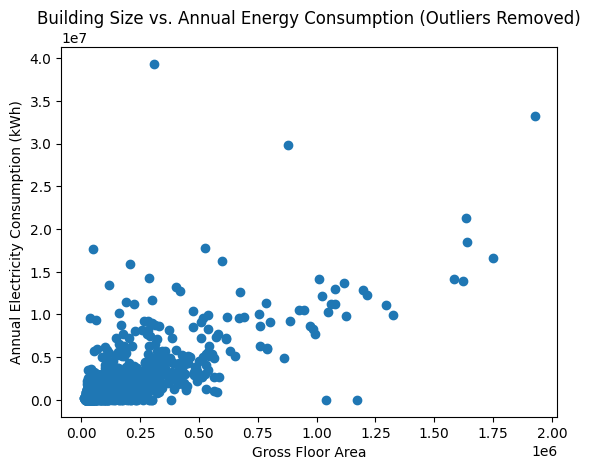

In [37]:
# Verify: re-plot without outliers

plt.scatter(x=df_noout['PropertyGFABuilding(s)'], y=df_noout['Electricity(kWh)'])

plt.title('Building Size vs. Annual Energy Consumption (Outliers Removed)')

plt.xlabel('Gross Floor Area')

plt.ylabel('Annual Electricity Consumption (kWh)')

plt.show()

Compare this chart to the earlier version. With the outliers removed, the overall pattern becomes much clearer: larger buildings generally consume more electricity.

---

## 7. Correlation



Correlation measures the linear relationship between two variables. It ranges from **-1** (perfect inverse relationship) to **+1** (perfect direct relationship). A value near **0** indicates no linear relationship.



> **Interpreting correlation values:**

> - A correlation of **+1** means that as one variable increases, the other increases proportionally.

> - A correlation of **-1** means that as one variable increases, the other decreases proportionally.

> - A correlation near **0** means there is no consistent linear pattern between the two variables.

>

> In practice, most real-world correlations fall somewhere in between. Values above **0.5** or below **-0.5** are generally considered moderately strong.

In [38]:
# Correlation matrix for numeric columns

df_noout.corr(numeric_only=True)

,OSEBuildingID,DataYear,ZipCode,Latitude,Longitude,CouncilDistrictCode,YearBuilt,NumberofFloors,NumberofBuildings,PropertyGFATotal,...,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,Electricity(kWh),SteamUse(kBtu),NaturalGas(therms),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
OSEBuildingID,1.000000,NaN,-0.224928,-0.021115,0.025804,0.001514,0.347554,0.018901,-0.016079,-0.070071,...,-0.084715,-0.027406,-0.005830,-0.141803,-0.031016,-0.069707,-0.119713,-0.069081,-0.074376,-0.035392
DataYear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZipCode,-0.224928,NaN,1.000000,-0.003425,0.003019,0.063447,-0.135127,-0.038241,0.011985,-0.021946,...,-0.018455,-0.024264,0.005375,0.000512,0.008642,0.006163,0.002130,0.006576,0.010090,0.020654
Latitude,-0.021115,NaN,-0.003425,1.000000,-0.999070,0.040109,-0.014764,0.009265,0.003248,0.000651,...,-0.003084,0.003947,0.003433,0.001070,0.001070,-0.000713,0.001400,-0.000890,0.000447,0.001674
Longitude,0.025804,NaN,0.003019,-0.999070,1.000000,-0.029600,0.019340,-0.010737,-0.002402,-0.002510,...,0.001303,-0.005198,-0.005078,-0.002357,-0.001419,0.000587,-0.002581,0.000460,-0.000873,-0.002349
CouncilDistrictCode,0.001514,NaN,0.063447,0.040109,-0.029600,1.000000,-0.088721,-0.034142,-0.038188,-0.133396,...,-0.125239,-0.114152,-0.085630,-0.122676,-0.026833,-0.063391,-0.126441,-0.065247,-0.066171,-0.010754
YearBuilt,0.347554,NaN,-0.135127,-0.014764,0.019340,-0.088721,1.000000,0.184357,0.005401,0.203338,...,0.181474,0.211941,0.092294,0.133807,0.000804,0.016400,0.134265,0.014330,0.019866,-0.149991
NumberofFloors,0.018901,NaN,-0.038241,0.009265,-0.010737,-0.034142,0.184357,1.000000,-0.027242,0.629509,...,0.635012,0.484008,0.254966,0.455171,0.069780,0.135491,0.448704,0.132386,0.164448,-0.058841
NumberofBuildings,-0.016079,NaN,0.011985,0.003248,-0.002402,-0.038188,0.005401,-0.027242,1.000000,0.262911,...,0.260790,0.165269,0.076083,0.264415,0.103624,0.287100,0.261691,0.282478,0.265585,0.035724
PropertyGFATotal,-0.070071,NaN,-0.021946,0.000651,-0.002510,-0.133396,0.203338,0.629509,0.262911,1.000000,...,0.963370,0.823309,0.416091,0.751536,0.278140,0.357461,0.745163,0.351227,0.471483,0.005300


**Reading the correlation matrix:** Each cell in this table shows the correlation between two columns. The diagonal is always 1.0, since every column is perfectly correlated with itself. Look for values that are far from 0 — these indicate potentially meaningful relationships. For example, a high positive correlation between floor area and electricity consumption suggests that building size is a strong predictor of energy use.

---

## Quick Reference



The following table summarizes the main commands introduced in this notebook.



| Task | Code |

|---|---|

| Load a CSV file | `df = pd.read_csv("filename.csv")` |

| Display the first 5 rows | `df.head()` |

| List column names | `df.columns` |

| Get row and column counts | `df.shape` |

| View data types and missing values | `df.info()` |

| Compute descriptive statistics | `df.describe()` |

| Select a single column | `df['ColumnName']` |

| Select rows by position | `df.iloc[0:5]` |

| Filter rows by a condition | `df[df['Column'] >= value]` |

| Combine filters with AND | `df[(condition1) & (condition2)]` |

| Combine filters with OR | `df[(condition1) \| (condition2)]` |

| Compute the mean | `df['Column'].mean()` |

| Compute min / max | `df['Column'].min()` / `.max()` |

| Create a histogram | `plt.hist(df['Column'], bins=30)` |

| Create a scatter plot | `plt.scatter(x=df['A'], y=df['B'])` |

| Compute a correlation matrix | `df.corr(numeric_only=True)` |